## DESCRIPCIÓN DEL PROYECTO:


Este proyecto tiene como objetivo analizar el comportamiento y la experiencia del usuario dentro de la aplicación para identificar los puntos de fricción en el proceso de compra y evaluar la viabilidad de un rediseño de interfaz.
El análisis se centra en optimizar el embudo de ventas y validar, mediante un test A/A/B, si los cambios en el diseño visual influyen en la conversión de los clientes.

* Los usuarios se dividen en tres grupos: dos grupos de control obtienen las fuentes antiguas y un grupo de prueba obtiene las nuevas.

## OBJETIVO:

1.-investigar el comportamiento del usuario para la aplicación de la empresa: estudiar el embudo de conversión, ¿cuántos usuarios llegan a cada etapa de venta?

2.-Realizar pruebas A/A/B para probar si cambiar las fuentes de toda la aplicación traen un efecto en ventas.


## PROCESO

1. Limpieza y preparación de datos

    * verificar balance de grupos para el experimento.

    * Estandarización de nombres de columnas.

    * Tratamiento de valores ausentes.

    * Conversión de columna de tipo fecha a dt.date.

2. Análisis exploratorio (EDA)

    * Tipo de eventos, cantidad de usuarios únicos, promedio de eventos por día y por usuario. 

    * Análisis por embudo: eventos y frecuencia.

   

3. Análisis estadístico

   * Pruebas de hipótesis (t-test) para comparar:

        * Determinar si los 3 grupos del experimento presentas diferencias considerables en las tasa de conversión.


## CONCLUSIONES:
Con relación al comportamiento del usuario en la plataforma dentro del periodo 25 julio a 07 de agosto de 2019:
* El evento mas visitado es el de Main screen appear con 119,205 interacciones.
* Se registran 7551 usuarios únicos.
* En promedio cada usuario tienen 32 interacciones con la aplicación.
* De la totaliad de usuarios, sólo el 11% de los usuarios vieron el tutorial, el 98% visitaron la pantalla principal, 61% vieron las ofertas, 49% agregaron productos a su carrito y 46% concluyeron su compra y pagaron.

Con relación al experimento:

*  El tamaño de las muestras son similares, distan de máximo 50 datos, un 2% de la muestra con mas datos (B:2540)
*  No hay diferencia entre las tasas de conversión de los grupos control A y A1 en las diferentes etapas.
*  Con un valor de significacia estadística de 0.05, no se tienen diferencia entre los gpo de control y el gpo B



### Se concluye que, de acuerdo a la prueba, el implementar un cambio de diseño en las fuentes de la aplicación, no trae cambios estadisticos significativos, por lo que se sugiere no realizar el cambio.

### CARGAR LIBRERÍAS

In [4]:
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

### 1.- LEER ARCHIVO

In [ ]:
data=pd.read_csv("logs_exp_us (2).csv", sep='\t')

### 2.-PREPARAR DATOS PARA EL ANÁLISIS

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   EventName       244126 non-null  str  
 1   DeviceIDHash    244126 non-null  int64
 2   EventTimestamp  244126 non-null  int64
 3   ExpId           244126 non-null  int64
dtypes: int64(3), str(1)
memory usage: 7.5 MB


In [7]:
data.sample(5)

,EventName,DeviceIDHash,EventTimestamp,ExpId
234783,MainScreenAppear,5135862823455609826,1565192471,246
170329,MainScreenAppear,5862057159286119848,1565026054,248
165199,CartScreenAppear,4000424917043781140,1565019298,248
124163,CartScreenAppear,5103709890545651598,1564922489,246
64231,MainScreenAppear,8569223309921894066,1564761191,248


In [8]:
data['EventName'].unique()

<StringArray>
[       'MainScreenAppear', 'PaymentScreenSuccessful',
        'CartScreenAppear',      'OffersScreenAppear',
                'Tutorial']
Length: 5, dtype: str

In [9]:
# Verificar si grupos están balanceados
data["ExpId"].value_counts(normalize = True)

ExpId
248    0.351241
246    0.328945
247    0.319814
Name: proportion, dtype: float64

## 2.1 Cambiar nombre de columnas

In [10]:
#cambiar nombre de columnas

data = data.rename(columns = {
    "EventName": "event",
    "DeviceIDHash": "user",
    "EventTimestamp": "timestamp",
    "ExpId": "group",
})


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   event      244126 non-null  str  
 1   user       244126 non-null  int64
 2   timestamp  244126 non-null  int64
 3   group      244126 non-null  int64
dtypes: int64(3), str(1)
memory usage: 7.5 MB


## 2.2 valores ausentes

In [12]:
data.isnull().sum()

event        0
user         0
timestamp    0
group        0
dtype: int64

In [13]:
# Ajustar la columna group: cambiar números por letras
grupo = {
    246: "A",
    247: "A1",
    248: "B"
}

data["group"] = data["group"].map(grupo)

## 2.3 columna de fecha y hora y columna para solo fecha 

In [14]:
# Cambiar el tipo de la columna timestamp
data["timestamp"] = pd.to_datetime(data["timestamp"], unit = "s")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   event      244126 non-null  str          
 1   user       244126 non-null  int64        
 2   timestamp  244126 non-null  datetime64[s]
 3   group      244126 non-null  str          
dtypes: datetime64[s](1), int64(1), str(2)
memory usage: 7.5 MB


In [15]:
# Extraer componente de dia del experimento
data["day"] = data["timestamp"].dt.date
data.sample(5)

,event,user,timestamp,group,day
232537,MainScreenAppear,2922305957979265233,2019-08-07 14:52:52,A1,2019-08-07
234039,OffersScreenAppear,2449529403513183576,2019-08-07 15:25:07,B,2019-08-07
14695,MainScreenAppear,4699227090087181127,2019-08-01 10:40:13,A,2019-08-01
80382,OffersScreenAppear,7759376189177788298,2019-08-03 07:57:56,A1,2019-08-03
124819,CartScreenAppear,2161145992201706665,2019-08-04 12:57:29,A,2019-08-04


### 3.- ESTUDIAR Y COMPROBAR LOS DATOS

### 3.1 ¿Cuántos eventos hay en los registros?

In [16]:
data['event'].value_counts()

event
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: count, dtype: int64

#### CONCLUSIÓN: El evento que más se visito fue la pantalla principal.

### 3.2 ¿Cuántos usuarios hay en los registros?

In [17]:
data['user'].nunique()

7551

##### CONCLUSIÓN: Se registran 7,551 usuarios únicos

### 3.3 ¿Cuál es el promedio de eventos por usuario?

In [18]:
prom_evento_usuarios= 244126/data['user'].nunique()
print(prom_evento_usuarios)

32.33028737915508


##### CONCLUSIÓN: Los usuarios en promedio tienen 32 eventos/visitas/interacción con la aplicación.

### 3.4 fecha máxima y mínima

In [19]:
data['timestamp'].describe()

count                 244126
mean     2019-08-04 10:18:35
min      2019-07-25 04:43:36
25%      2019-08-02 14:36:20
50%      2019-08-04 11:49:55
75%      2019-08-06 06:55:11
max      2019-08-07 21:15:17
Name: timestamp, dtype: object

In [20]:
data['day']=pd.to_datetime(data['day'])

In [21]:
grafico_day=data["day"].value_counts().sort_index()
print(grafico_day)

day
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      413
2019-07-31     2031
2019-08-01    36229
2019-08-02    35606
2019-08-03    33351
2019-08-04    33033
2019-08-05    36113
2019-08-06    35822
2019-08-07    31144
Name: count, dtype: int64


In [22]:
grafico_day.index = grafico_day.index.astype(str)




##### La información abarca visitas de usuarios a la app del 25 de julio al 7 de agosto de 2019.

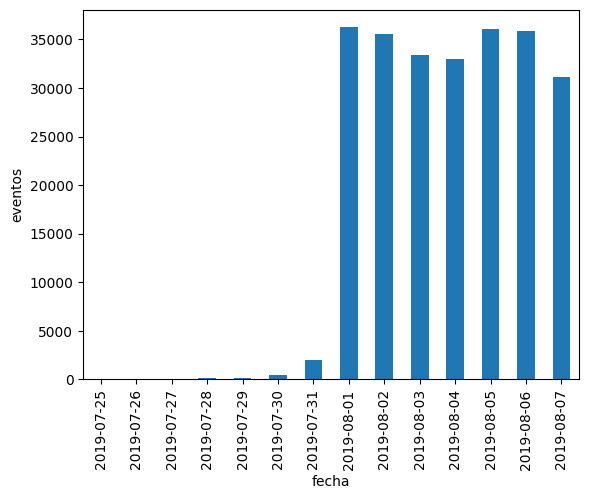

In [23]:
grafico_day.plot(kind='bar',
                      xlabel='fecha',
                      ylabel='eventos')

plt.show()

### 4.-ESTUDIAR EL EMBUDO DE EVENTOS

In [24]:
data.sample(7)

,event,user,timestamp,group,day
223488,OffersScreenAppear,4612600107457375865,2019-08-07 10:18:04,B,2019-08-07
112897,MainScreenAppear,3670880358399219515,2019-08-04 07:31:46,A1,2019-08-04
23087,PaymentScreenSuccessful,5839029156906299130,2019-08-01 14:10:02,B,2019-08-01
119635,CartScreenAppear,4713748699910253089,2019-08-04 10:50:57,B,2019-08-04
174071,CartScreenAppear,4148267947677649217,2019-08-05 19:29:38,B,2019-08-05
147425,MainScreenAppear,7256797426086565332,2019-08-05 07:59:21,A,2019-08-05
40900,CartScreenAppear,6304868067479728361,2019-08-02 02:42:44,B,2019-08-02


#### 4.1.- Eventos y frecuencia

In [25]:
data['event'].value_counts()

event
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: count, dtype: int64

#### 4.2  cantidad de usuarios que realizaron cada una de estas acciones. Ordenar los eventos por el número de usuarios. Calcular la proporción de usuarios que realizaron la acción al menos una vez

In [26]:
cantidad_usuarios_evento=data.groupby('event')['user'].nunique().sort_values(ascending=False).reset_index()
print(cantidad_usuarios_evento)

                     event  user
0         MainScreenAppear  7439
1       OffersScreenAppear  4613
2         CartScreenAppear  3749
3  PaymentScreenSuccessful  3547
4                 Tutorial   847


In [27]:
cantidad_usuarios_evento['proporcion']=(cantidad_usuarios_evento['user']/data['user'].nunique())*100
print(cantidad_usuarios_evento)

                     event  user  proporcion
0         MainScreenAppear  7439   98.516753
1       OffersScreenAppear  4613   61.091246
2         CartScreenAppear  3749   49.649053
3  PaymentScreenSuccessful  3547   46.973911
4                 Tutorial   847   11.217057


#### CONCLUSIÓN: de la totaliad de usuarios, sólo el 11% de los usuarios vieron el tutorial, el 98% visistaron la pantalla principal, 61% vieorn las ofertas, 49% agregaron productos a su carrito y 46% concluyeron su compra y pagaron,

In [28]:
print(cantidad_usuarios_evento)

                     event  user  proporcion
0         MainScreenAppear  7439   98.516753
1       OffersScreenAppear  4613   61.091246
2         CartScreenAppear  3749   49.649053
3  PaymentScreenSuccessful  3547   46.973911
4                 Tutorial   847   11.217057


In [29]:
data = data.query("event != 'Tutorial'")

In [30]:
cantidad_usuarios_evento=cantidad_usuarios_evento.query("event != 'Tutorial'")
print(cantidad_usuarios_evento)

                     event  user  proporcion
0         MainScreenAppear  7439   98.516753
1       OffersScreenAppear  4613   61.091246
2         CartScreenAppear  3749   49.649053
3  PaymentScreenSuccessful  3547   46.973911


### 4.4 Embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente. Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B.

In [31]:
cantidad_usuarios_evento['conversión_%']=(cantidad_usuarios_evento['user']/7439)*100
print(cantidad_usuarios_evento)
cantidad_usuarios_evento['proporción_Etapas']=(cantidad_usuarios_evento['user']/7439)*100

                     event  user  proporcion  conversión_%
0         MainScreenAppear  7439   98.516753    100.000000
1       OffersScreenAppear  4613   61.091246     62.011023
2         CartScreenAppear  3749   49.649053     50.396559
3  PaymentScreenSuccessful  3547   46.973911     47.681140


In [32]:
orden = ['MainScreenAppear','OffersScreenAppear','CartScreenAppear','PaymentScreenSuccessful']
cuentas = data.query("event != 'Tutorial'").groupby('event')['user'].nunique().reindex(orden)
# Conv. acumulada desde inicio y por etapa
conv_desde_inicio = (100 * cuentas / cuentas.iloc[0]).round(2)
conv_por_etapa = [100.0] + list((100 * (cuentas.iloc[1:].values / cuentas.iloc[:-1].values)).round(2))
# Integra al DataFrame existente siguiendo el mismo orden
df_embudo = cantidad_usuarios_evento.set_index('event').reindex(orden)
df_embudo['conv_desde_inicio_%'] = conv_desde_inicio.values
df_embudo['conv_por_etapa_%'] = conv_por_etapa
print(df_embudo.reset_index())

                     event  user  proporcion  conversión_%  proporción_Etapas  \
0         MainScreenAppear  7439   98.516753    100.000000         100.000000   
1       OffersScreenAppear  4613   61.091246     62.011023          62.011023   
2         CartScreenAppear  3749   49.649053     50.396559          50.396559   
3  PaymentScreenSuccessful  3547   46.973911     47.681140          47.681140   

   conv_desde_inicio_%  conv_por_etapa_%  
0               100.00            100.00  
1                62.01             62.01  
2                50.40             81.27  
3                47.68             94.61  


proporcion: considera al total 7551
conversion: considera el total de los usuario que pasaron a la primera etapa: Mainscreenappear: 7439
proporcion por etapas: igual que el anterior *se repite**
conv_desde_inicio: considera el total de los usuarios que pasaron a la primera etapa.
conv_desde_inicio_%v: considera el total de los usuario que pasaron a la primera etapa: Mainscreenappear.
conv_por_etapa_% : considera el total de la etapa anterior

#### CONCLUSIÓN: De los 7551 usuarios registrados, 7439 usuarios llegaron a visualizar la pantalla principal, 112 usuarios no llegaron a ese evento.
#### 62% (4613 usuarios) visualizarn la pantalla de ofertas de esos usuarios, 50.3% de los usuarios llegaron a la pantalla del carrito y 46.97 llegaron hasta la etapa de pago.


#### CONCLUSIÓN:  De los usuarios que visitaron la pantalla principal el 50.39% pasaron a la pantalla del carrito, de ese 81% casi todos, el 94.6% realizaron el pago. En la etapa de pantalla principal a la etapa de ofertas se pierden mas usuarios, un 61% considerando la totalidad de usuarios y un 62% considerando como total los usuarios que visitan la pantalla principal. 46% de lso usuarios hacen todo el viaje, desde la etapa de la pantalla principal hasta realziar el pago.

#### 5.- ESTUDIAR LOS RESULTADOS DEL EXPERIMENTO

#### Usuarios por Grupo

In [33]:
data.sample(7)

,event,user,timestamp,group,day
123283,CartScreenAppear,4713748699910253089,2019-08-04 12:21:54,B,2019-08-04
161153,MainScreenAppear,2336714371076846454,2019-08-05 14:13:15,A,2019-08-05
95287,MainScreenAppear,3921210056250168865,2019-08-03 14:26:34,A,2019-08-03
127664,MainScreenAppear,1449633191757318122,2019-08-04 14:19:17,B,2019-08-04
132950,MainScreenAppear,3440798197632135663,2019-08-04 16:40:04,A1,2019-08-04
205506,CartScreenAppear,9115449445501491156,2019-08-06 17:17:33,B,2019-08-06
74357,OffersScreenAppear,4891397824124625593,2019-08-02 22:30:00,A1,2019-08-02


In [34]:
usuarios_gpo=data.groupby('group')['user'].nunique()
print(usuarios_gpo)

group
A     2488
A1    2519
B     2540
Name: user, dtype: int64


#### El tamaño de las muestras son similares, distan de máximo 50 datos, un 2% de la muestra con mas datos (B:2540)

### Tasas de conversión por grupos

In [35]:

conv_grupos = data.pivot_table(
    index = "event",
    columns = "group",
    values = "user",
    aggfunc = "nunique"
).sort_values(by = "A", ascending = False)

print(conv_grupos)

group                       A    A1     B
event                                    
MainScreenAppear         2456  2482  2501
OffersScreenAppear       1545  1530  1538
CartScreenAppear         1270  1240  1239
PaymentScreenSuccessful  1202  1160  1185


In [36]:
conv_rel = (100 * conv_grupos.div(conv_grupos.loc['MainScreenAppear'])).round(2)
print(conv_rel)

group                         A      A1       B
event                                          
MainScreenAppear         100.00  100.00  100.00
OffersScreenAppear        62.91   61.64   61.50
CartScreenAppear          51.71   49.96   49.54
PaymentScreenSuccessful   48.94   46.74   47.38


### Comprobar si la diferencia entre los grupos de control es estadísticamente significativa

#### Hipótesis nula: no hay diferencia entre las tasas de conv de los dos gpo de control,son iguales
#### Hipótesis alternativa: Hay diferencia entre las tasas de conv de los gpo de control, no son iguales.

In [37]:
# Extraer muestras de ambos grupos
muestra_1 = data.query("group == 'A'")
muestra_2 = data.query("group == 'A1'") 

# Obtener cantidad de usuarios totales
nobs = [
    muestra_1["user"].nunique(),
    muestra_2["user"].nunique()
]

# Obtener cantidad de casos convertidos
suc = [
    muestra_1.query("event == 'MainScreenAppear'")["user"].nunique(),
    muestra_2.query("event == 'MainScreenAppear'")["user"].nunique()
]

print("CASOS TOTALES:")
print(nobs)
print("CASOS EXITOSOS:")
print(suc)

CASOS TOTALES:
[2488, 2519]
CASOS EXITOSOS:
[2456, 2482]


In [38]:
# Ejecutar prueba estadistica
z, p = proportions_ztest(
    count = suc, 
    nobs = nobs, 
    alternative = "two-sided"
)

if p < 0.05:
    print("RECHAZO H0")
else:
    print("NO RECHAZO H0")
    
print(f"Valor p: {p:.05%}")

NO RECHAZO H0
Valor p: 57.93437%


#### CONCLUSIÓN: La tasa de conversion en la etapa de pantalla principal, no es diferente entre las dos muestras de control (A y A1), por lo que no se rechaza hipótesis.

#### Realizar función y probar las hipotesis en etapas restantes.

In [39]:
# Funcion para test de hipotesis
def prueba_ab (g1, g2, etapa, alt = "two-sided"):

    print("PRUEBA EN ETAPA:",etapa)

    # Extraer muestras de ambos grupos
    muestra_1 = data.query("group == @g1")
    muestra_2 = data.query("group == @g2")

    # Obtener cantidad de usuarios totales
    nobs = [
        muestra_1["user"].nunique(),
        muestra_2["user"].nunique()
    ]

    # Obtener cantidad de casos convertidos
    suc = [
        muestra_1.query("event == @etapa")["user"].nunique(),
        muestra_2.query("event == @etapa")["user"].nunique()
    ]

    # Ejecutar prueba estadistica
    z, p = proportions_ztest(
        count = suc, 
        nobs = nobs, 
        alternative = alt
    )

    if p < 0.05:
        print("RECHAZO H0")
    else:
        print("NO RECHAZO H0")
    
    print(f"Valor p: {p:.05%}")

    # Calcular intervalos de confianza para ambos grupos
    (inf_1, inf_2), (sup_1, sup_2) = proportion_confint(
        count = suc,
        nobs = nobs,
        alpha = 0.05
    )



In [40]:
prueba_ab('A','A1','OffersScreenAppear')

PRUEBA EN ETAPA: OffersScreenAppear
NO RECHAZO H0
Valor p: 32.30607%


In [41]:
prueba_ab('A','A1','CartScreenAppear')

PRUEBA EN ETAPA: CartScreenAppear
NO RECHAZO H0
Valor p: 19.80243%


In [42]:
prueba_ab('A','A1','PaymentScreenSuccessful')


PRUEBA EN ETAPA: PaymentScreenSuccessful
NO RECHAZO H0
Valor p: 10.89259%


#### CONCLUSIÓN: No hay diferencia entre las tasas de conversión de los grupos control A y A1.
    

### PRUEBA AB CONTROL (A O A2) CON B

In [43]:
prueba_ab('A','B','MainScreenAppear')

PRUEBA EN ETAPA: MainScreenAppear
NO RECHAZO H0
Valor p: 45.38875%


In [44]:
prueba_ab('A','B','OffersScreenAppear')

PRUEBA EN ETAPA: OffersScreenAppear
NO RECHAZO H0
Valor p: 26.01501%


In [45]:
prueba_ab('A','B','CartScreenAppear')

PRUEBA EN ETAPA: CartScreenAppear
NO RECHAZO H0
Valor p: 10.81995%


In [46]:
prueba_ab('A','B','PaymentScreenSuccessful')

PRUEBA EN ETAPA: PaymentScreenSuccessful
NO RECHAZO H0
Valor p: 23.90549%


### CONCLUSIÓN_1: Con un valor de significacia estadística de 0.1, no se tienen diferencia entre los gpo de control y el gpo B.

### CONCLUSIÓN_2: Con un valor de significacia estadística de 0.05, no se tienen diferencia entre los gpo de control y el gpo B.

### Se concluye que, de acuerdo a la prueba, el implementar un cambio de diseño en las fuentes de la aplicación, no trae cambios estadisticos significativos, por lo que se sugiere no realizar el cambio.